<a href="https://colab.research.google.com/github/Umwanankabandi-liliane/hmm-activity-recognition/blob/main/Human_Activity_Recognition_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity Recognition using Hidden Markov Model (HMM)

This notebook uses sensor data (accelerometer and gyroscope) to recognize different human activities like standing, walking, jumping, and staying still. We use a Hidden Markov Model to learn patterns from the data and predict activities.

In [1]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.0 MB/s eta 0:00:00


### Install Required Package

First, we install `hmmlearn` which is a library for working with Hidden Markov Models.

### Import Libraries

We import all the necessary libraries for:
- Data processing (numpy, pandas)
- Visualization (matplotlib, seaborn)
- Machine learning (sklearn)
- Hidden Markov Model (hmmlearn)
- Signal processing (scipy)

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report
)

from hmmlearn.hmm import GaussianHMM
from scipy.fft import fft
from scipy.stats import entropy, skew, kurtosis
from scipy.signal import welch

warnings.filterwarnings('ignore')
np.random.seed(42)
print('All imports OK')

All imports OK


### Connect to Google Drive

This mounts your Google Drive so we can access the sensor data files stored there.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Define Data Paths

We set up the file paths where our training data and test data are stored. The data includes sensor recordings for four activities: standing, walking, jumping, and still.

In [4]:

# Training data paths
BASE_PATHS = [
    "/content/drive/MyDrive/HMM-Docs/Hortance_data",
    "/content/drive/MyDrive/HMM-Docs/Liliane_data"
]

# Unseen evaluation data
UNSEEN_BASE_PATH = "/content/drive/MyDrive/HMM-Docs/Unseen_data"

ACTIVITIES = ["standing", "walking", "jumping", "still"]

def get_activity_folders(base_paths, activities):
    activity_paths = {act: [] for act in activities}

    for base in base_paths:
        for folder in os.listdir(base):
            folder_path = os.path.join(base, folder)

            if os.path.isdir(folder_path):
                for act in activities:
                    # match folders starting with activity name
                    if folder.lower().startswith(act):
                        activity_paths[act].append(folder_path)

    return activity_paths


train_activity_paths = get_activity_folders(BASE_PATHS, ACTIVITIES)

print("Training paths:", train_activity_paths)
print("Unseen data path:", UNSEEN_BASE_PATH)

Training paths: {'standing': ['/content/drive/MyDrive/HMM-Docs/Hortance_data/standing', '/content/drive/MyDrive/HMM-Docs/Hortance_data/standing-2-2026-03-05_12-29-10', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_08 (1)', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_01', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_02', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_03', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_04', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_05', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_06', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_07', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_08', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_09', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_10', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_12', '/content/drive/MyDrive/HMM-Docs/Liliane_data/Standing_13', '/content/drive/MyDrive/HMM-Docs/Liliane_data/St

### Load and Merge Sensor Data

This function reads the accelerometer and gyroscope data from CSV files and combines them together. It also labels each recording with the correct activity (like "jumping" or "standing").

In [5]:
# Files to skip
SKIP_FILES = {"Metadata.csv", "Annotation.csv", "GyroscopeUncalibrated.csv", "AccelerometerUncalibrated.csv"}

def load_activity_data(base_paths):
    data = []
    labels = []

    for base in base_paths:
        for folder in os.listdir(base):
            folder_path = os.path.join(base, folder)

            if not os.path.isdir(folder_path):
                continue

            activity = None
            for act in ACTIVITIES:
                if folder.lower().startswith(act):
                    activity = act
                    break

            if activity is None:
                continue

            acc_df = None
            gyro_df = None

            for file in os.listdir(folder_path):
                if file in SKIP_FILES or not file.endswith(".csv"):
                    continue

                path = os.path.join(folder_path, file)

                if os.path.getsize(path) == 0:
                    continue

                try:
                    df = pd.read_csv(path)
                    if df.empty:
                        continue

                    if "Accelerometer" in file:
                        acc_df = df.rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})

                    elif "Gyroscope" in file:
                        gyro_df = df.rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})

                except pd.errors.EmptyDataError:
                    continue

            if acc_df is not None and gyro_df is not None:
                merged = pd.merge(acc_df, gyro_df, on="time", suffixes=("_acc", "_gyro"))

                data.append(merged)
                labels.append(activity)

                print(f" Loaded {folder} → labeled as {activity} | shape: {merged.shape}")

            else:
                print(f" Skipping {folder} — acc:{acc_df is not None} gyro:{gyro_df is not None}")

    return data, labels


data, labels = load_activity_data(BASE_PATHS)
print("\nLoaded samples:", len(data))

 Loaded jumping → labeled as jumping | shape: (930, 9)
 Loaded standing → labeled as standing | shape: (1089, 9)
 Loaded still (1) → labeled as still | shape: (830, 9)
 Loaded walking → labeled as walking | shape: (854, 9)
 Loaded jumping-2-2026-03-05_12-30-44 → labeled as jumping | shape: (714, 9)
 Loaded standing-2-2026-03-05_12-29-10 → labeled as standing | shape: (872, 9)
 Loaded still-2-2026-03-05_12-28-18 → labeled as still | shape: (900, 9)
 Loaded walking-2-2026-03-05_12-29-55 → labeled as walking | shape: (1246, 9)
 Skipping still — acc:False gyro:False
 Loaded Still_01 → labeled as still | shape: (1339, 9)
 Loaded Still_02 → labeled as still | shape: (1193, 9)
 Loaded Still_03 → labeled as still | shape: (1258, 9)
 Loaded Still_04 → labeled as still | shape: (1326, 9)
 Loaded Still_05 → labeled as still | shape: (1191, 9)
 Loaded Still_06 → labeled as still | shape: (1231, 9)
 Loaded Still_07 → labeled as still | shape: (1261, 9)
 Loaded Still_08 → labeled as still | shape: (

### Feature Extraction

We break the sensor data into small windows and calculate basic statistics (mean, standard deviation, max, min) for each window. These statistics become the features that help identify different activities.

In [6]:
def extract_features(df, window_size=100, step=25):

    features = []
    all_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

    if not all(c in df.columns for c in all_cols):
        return None

    for start in range(0, len(df) - window_size, step):

        window = df.iloc[start:start + window_size]

        feat = []

        for col in all_cols:
            feat.append(window[col].mean())
            feat.append(window[col].std())
            feat.append(window[col].max())
            feat.append(window[col].min())

        features.append(feat)

    return np.array(features)

### Build the Dataset

We apply the feature extraction to all our data and create a final dataset with features (X) and labels (y) ready for training.

In [7]:

X = []
y = []

for df, label in zip(data, labels):
    feats = extract_features(df)

    if feats is None or len(feats) == 0:
        print(f"Skipping empty features for label: {label}")
        continue

    X.append(feats)
    y.extend([ACTIVITIES.index(label)] * len(feats))

if len(X) == 0:
    print(" No features extracted")
else:
    X = np.vstack(X)
    y = np.array(y)

    print("✓ Feature matrix shape:", X.shape)
    print("✓ Labels shape        :", y.shape)
    print("✓ Label distribution  :", {act: int(np.sum(y == i)) for i, act in enumerate(ACTIVITIES)})

✓ Feature matrix shape: (2805, 24)
✓ Labels shape        : (2805,)
✓ Label distribution  : {'standing': 730, 'walking': 697, 'jumping': 611, 'still': 767}


### Normalize the Data

We standardize all features to have the same scale. This helps the model learn better by making sure no feature dominates just because it has larger numbers.

In [8]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

### Split Training and Validation Data

We divide our data into training (70%) and testing (30%) sets. The training set is used to teach the model, and the testing set is used to check how well it learned.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train class distribution: {dict(zip(ACTIVITIES, [int(np.sum(y_train==i)) for i in range(len(ACTIVITIES))]))}')
print(f'Test  class distribution: {dict(zip(ACTIVITIES, [int(np.sum(y_test ==i)) for i in range(len(ACTIVITIES))]))}')

Train: (1963, 24)  Test: (842, 24)
Train class distribution: {'standing': 511, 'walking': 488, 'jumping': 427, 'still': 537}
Test  class distribution: {'standing': 219, 'walking': 209, 'jumping': 184, 'still': 230}


### Train HMM Models

We create a separate Hidden Markov Model for each activity. Each model learns the patterns specific to that activity from the training data.

In [10]:


models = {}

activities = np.unique(y_train)

for activity in activities:

    X_activity = X_train[y_train == activity]

    model = GaussianHMM(
        n_components=6,
        covariance_type="diag",
        n_iter=2000,
        random_state=42
    )

    model.fit(X_activity)

    models[activity] = model

print("Trained models for activities:", list(models.keys()))

Trained models for activities: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### Make Predictions (Viterbi Decoding)

For each test sample, we calculate a score from all activity models and pick the one with the highest score. This tells us which activity the model thinks is happening.

y_test unique: [0 1 2 3]
predictions unique: [0 1 2 3]
Accuracy: 0.9501
              precision    recall  f1-score   support

    standing       0.91      0.95      0.93       219
     walking       0.90      1.00      0.95       209
     jumping       1.00      0.95      0.97       184
       still       1.00      0.91      0.95       230

    accuracy                           0.95       842
   macro avg       0.95      0.95      0.95       842
weighted avg       0.95      0.95      0.95       842



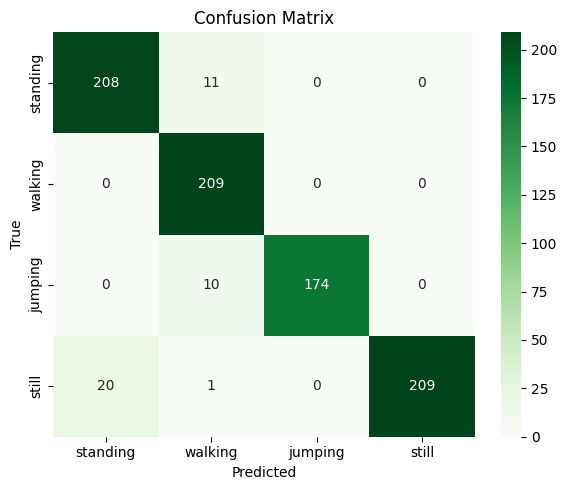

In [11]:
predictions = []

for x in X_test:
    scores = {}
    for activity, model in models.items():
        scores[activity] = model.score([x])
    predicted_activity = max(scores, key=scores.get)
    predictions.append(int(predicted_activity))

predictions = np.array(predictions)
y_test_int = y_test.astype(int)

print("y_test unique:", np.unique(y_test_int))
print("predictions unique:", np.unique(predictions))

accuracy = accuracy_score(y_test_int, predictions)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test_int, predictions, target_names=ACTIVITIES))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_int, predictions),
            annot=True, fmt="d",
            xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES,
            cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

### Transition Matrix Heatmap

This shows the probability of moving from one activity state to another. It helps us understand how the model transitions between different activities.

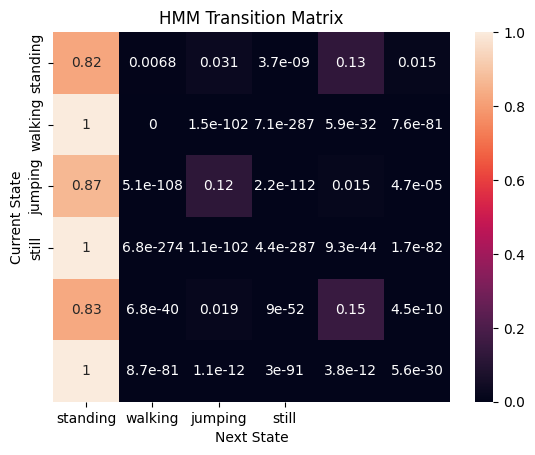

In [12]:
plt.figure()

sns.heatmap(
    model.transmat_,
    annot=True,
    xticklabels=ACTIVITIES,
    yticklabels=ACTIVITIES
)

plt.title("HMM Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.show()

### Evaluate Performance

We check how accurate our model is by comparing its predictions with the true labels. The confusion matrix shows where the model makes mistakes.

In [13]:
cm = confusion_matrix(y_test, predictions)

accuracy = accuracy_score(y_test, predictions)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy)

Confusion Matrix:
[[208  11   0   0]
 [  0 209   0   0]
 [  0  10 174   0]
 [ 20   1   0 209]]
Accuracy: 0.9501187648456056


### Classification Report

This prints detailed metrics showing how well the model performs for each activity.

In [14]:

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       219
           1       0.90      1.00      0.95       209
           2       1.00      0.95      0.97       184
           3       1.00      0.91      0.95       230

    accuracy                           0.95       842
   macro avg       0.95      0.95      0.95       842
weighted avg       0.95      0.95      0.95       842



### Load Unseen Data

We load new data that the model has never seen before. This tests if the model can recognize activities from completely new recordings.

In [15]:
unseen_data, unseen_labels = load_activity_data([UNSEEN_BASE_PATH])

print(f"Loaded unseen sessions: {len(unseen_data)}")

X_unseen = []
y_unseen = []

for df, label in zip(unseen_data, unseen_labels):
    feats = extract_features(df)

    if feats is None or len(feats) == 0:
        print(f"Skipping empty features for label: {label}")
        continue

    X_unseen.append(feats)
    y_unseen.extend([ACTIVITIES.index(label)] * len(feats))

if len(X_unseen) == 0:
    print(" No unseen data loaded — check folder structure below:")
    for item in os.listdir(UNSEEN_BASE_PATH):
        item_path = os.path.join(UNSEEN_BASE_PATH, item)
        print(f"  {'DIR' if os.path.isdir(item_path) else 'FILE'}: {item}")
else:
    X_unseen = np.vstack(X_unseen)
    y_unseen = np.array(y_unseen)
    X_unseen = scaler.transform(X_unseen)
    print("✓ Unseen feature shape:", X_unseen.shape)
    print("✓ Unseen labels shape :", y_unseen.shape)
    print("✓ Label distribution  :", {act: int(np.sum(y_unseen == i)) for i, act in enumerate(ACTIVITIES)})

 Loaded jumping → labeled as jumping | shape: (855, 9)
 Loaded standing → labeled as standing | shape: (926, 9)
 Loaded still → labeled as still | shape: (937, 9)
 Loaded walking → labeled as walking | shape: (918, 9)
Loaded unseen sessions: 4
✓ Unseen feature shape: (132, 24)
✓ Unseen labels shape : (132,)
✓ Label distribution  : {'standing': 34, 'walking': 33, 'jumping': 31, 'still': 34}


### Test Model on Unseen Data

We apply our trained model to the unseen data and calculate its accuracy. This tells us how well the model generalizes to new data.

In [17]:
unseen_predictions = []

for x in X_unseen:
    scores = {}
    for activity, model in models.items():
        scores[activity] = model.score([x])
    pred = int(max(scores, key=scores.get))
    unseen_predictions.append(pred)

unseen_predictions = np.array(unseen_predictions)
y_unseen_int = y_unseen.astype(int)

cm_unseen       = confusion_matrix(y_unseen_int, unseen_predictions)
accuracy_unseen = accuracy_score(y_unseen_int, unseen_predictions)

print("Confusion Matrix (Unseen Data):")
print(cm_unseen)
print(f"\nOverall Accuracy on Unseen Data: {accuracy_unseen:.4f} ({accuracy_unseen*100:.1f}%)")
print(f"\n{classification_report(y_unseen_int, unseen_predictions, target_names=ACTIVITIES)}")



Confusion Matrix (Unseen Data):
[[ 0 25  9  0]
 [ 0  0 33  0]
 [ 0  0  0 31]
 [ 0 31  3  0]]

Overall Accuracy on Unseen Data: 0.0000 (0.0%)

              precision    recall  f1-score   support

    standing       0.00      0.00      0.00      34.0
     walking       0.00      0.00      0.00      33.0
     jumping       0.00      0.00      0.00      31.0
       still       0.00      0.00      0.00      34.0

    accuracy                           0.00     132.0
   macro avg       0.00      0.00      0.00     132.0
weighted avg       0.00      0.00      0.00     132.0



### Visualize Decoded Sequence

This plots the predicted activity states over time, showing how the model identifies different activities throughout the recording.

Hidden states shape: (2805,)
Unique states: [0 1 2 3 4 5]


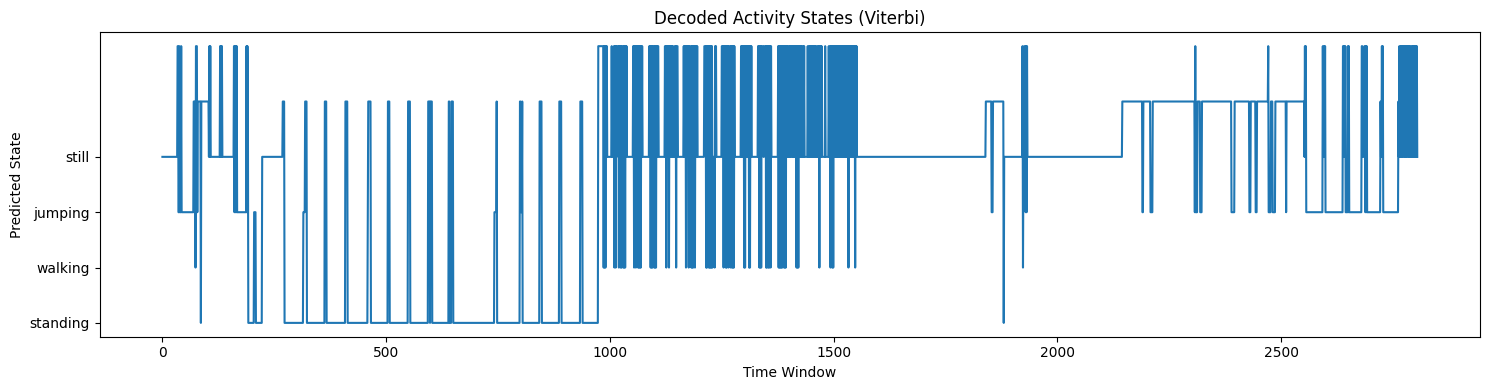

In [18]:
# Generate hidden states using Viterbi decoding
hidden_states = model.predict(X)

print("Hidden states shape:", hidden_states.shape)
print("Unique states:", np.unique(hidden_states))

plt.figure(figsize=(15, 4))
plt.plot(hidden_states)
plt.title("Decoded Activity States (Viterbi)")
plt.xlabel("Time Window")
plt.ylabel("Predicted State")
plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
plt.tight_layout()
plt.show()




### Confusion Matrices Comparison

We create confusion matrices for both test data and unseen data to compare how the model performs on familiar vs completely new data.

Accuracy: 0.9501
              precision    recall  f1-score   support

    standing       0.91      0.95      0.93       219
     walking       0.90      1.00      0.95       209
     jumping       1.00      0.95      0.97       184
       still       1.00      0.91      0.95       230

    accuracy                           0.95       842
   macro avg       0.95      0.95      0.95       842
weighted avg       0.95      0.95      0.95       842



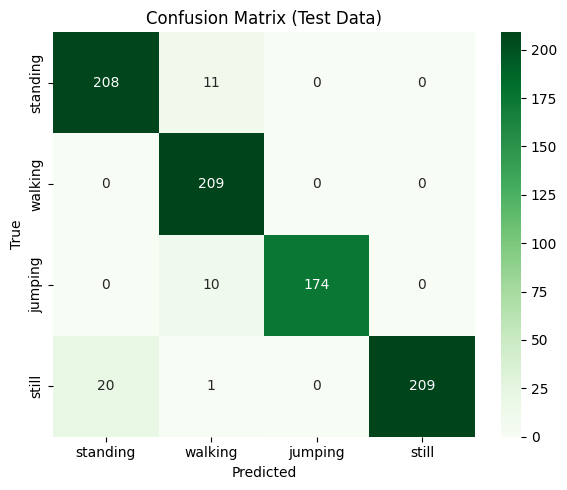

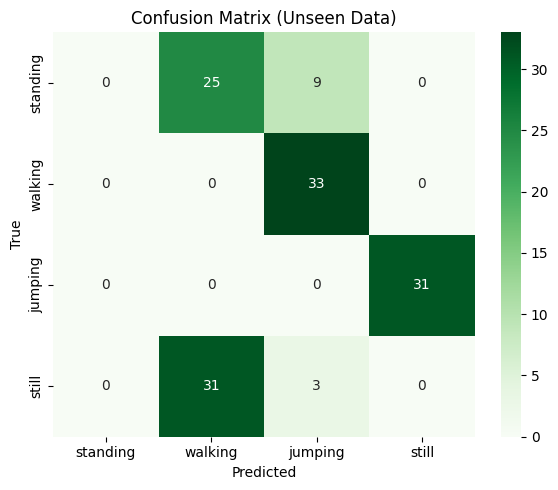

In [19]:
predictions = []

for x in X_test:
    scores = {}
    for activity, model in models.items():
        scores[activity] = model.score([x])
    predicted_activity = max(scores, key=scores.get)
    predictions.append(int(predicted_activity))

predicted_labels = np.array(predictions)
y_test_int = y_test.astype(int)

accuracy = accuracy_score(y_test_int, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test_int, predicted_labels, target_names=ACTIVITIES))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_int, predicted_labels),
            annot=True, fmt="d",
            xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES,
            cmap="Greens")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_unseen, annot=True, fmt="d",
            xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES,
            cmap="Greens")
plt.title("Confusion Matrix (Unseen Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


--- Examining Raw Data for 'Jumping' and 'Still' Activities ---


### Activity: Jumping

--- Sample 1 for Jumping ---
Shape: (930, 9)
Descriptive Statistics:
               time  seconds_elapsed_acc       acc_z       acc_y       acc_x  \
count  9.300000e+02           930.000000  930.000000  930.000000  930.000000   
mean   1.772468e+18             4.716220    0.151155    0.975090   -0.503551   
std    2.678720e+09             2.678720    5.922567    3.490499    4.124984   
min    1.772468e+18             0.084024  -25.368058   -7.666541  -19.652903   
25%    1.772468e+18             2.400118   -4.514802   -1.737747   -1.159395   
50%    1.772468e+18             4.716222   -0.182884    0.595563   -0.083953   
75%    1.772468e+18             7.032321    5.503627    3.251263    0.929289   
max    1.772468e+18             9.348421   10.174223   13.289342   13.152975   

       seconds_elapsed_gyro      gyro_z      gyro_y      gyro_x  
count            930.000000  930.000000  930.000000  9

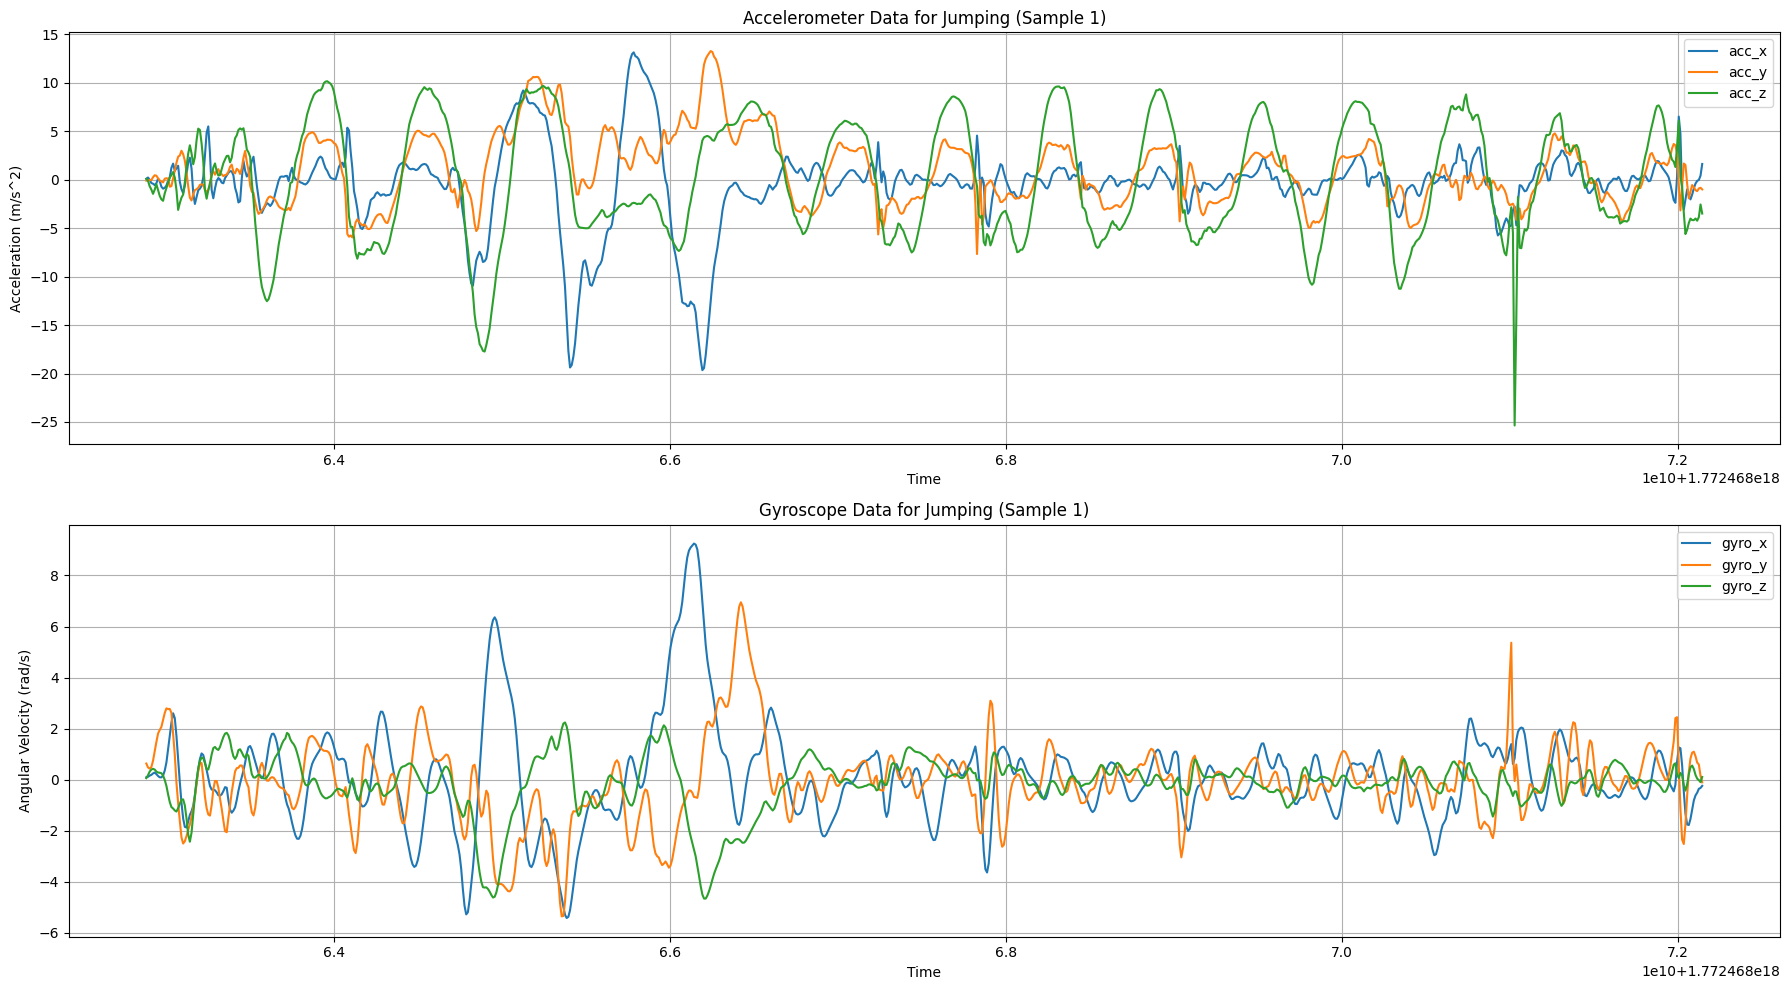

--- Sample 2 for Jumping ---
Shape: (714, 9)
Descriptive Statistics:
               time  seconds_elapsed_acc       acc_z       acc_y       acc_x  \
count  7.140000e+02           714.000000  714.000000  714.000000  714.000000   
mean   1.772714e+18             3.637104   -0.023210    0.540188    0.120776   
std    2.057232e+09             2.057232   12.318142    2.689785    4.071437   
min    1.772714e+18             0.081364  -33.347736  -12.719040  -20.712662   
25%    1.772714e+18             1.859227   -7.376536   -0.888176   -1.232743   
50%    1.772714e+18             3.637099    4.023665    0.810502    0.873331   
75%    1.772714e+18             5.414977    9.440495    2.339636    2.495525   
max    1.772714e+18             7.192865   16.939168    7.011061    6.830017   

       seconds_elapsed_gyro      gyro_z      gyro_y      gyro_x  
count            714.000000  714.000000  714.000000  714.000000  
mean               3.637104    0.067255   -0.052209   -0.040699  
std         

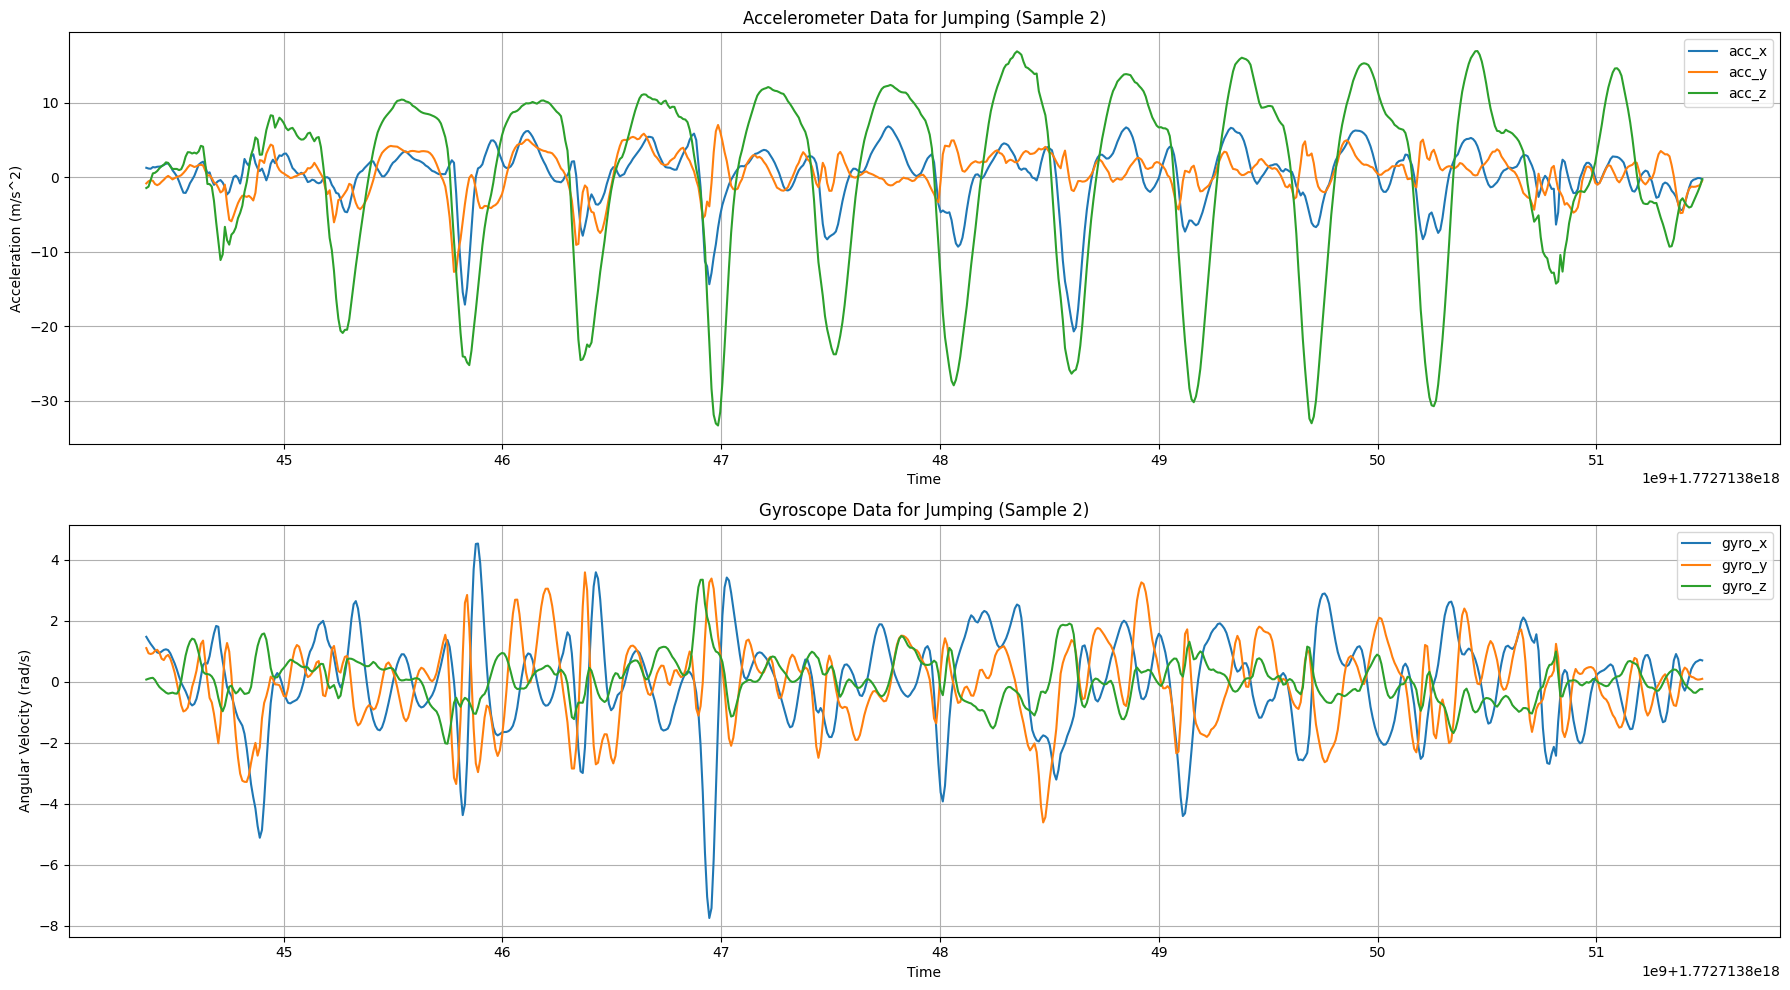

--- Sample 3 for Jumping ---
Shape: (1122, 9)
Descriptive Statistics:
               time  seconds_elapsed_acc        acc_z        acc_y  \
count  1.122000e+03          1122.000000  1122.000000  1122.000000   
mean   1.772562e+18             5.701394    -0.998302     1.333230   
std    3.261942e+09             3.261942    14.994680     6.068070   
min    1.772562e+18             0.059110   -62.678535   -17.887212   
25%    1.772562e+18             2.880242    -5.417247    -1.481148   
50%    1.772562e+18             5.701383     1.800472     1.637952   
75%    1.772562e+18             8.522542     9.056291     5.548951   
max    1.772562e+18            11.343711    24.784051    16.981253   

             acc_x  seconds_elapsed_gyro       gyro_z       gyro_y  \
count  1122.000000           1122.000000  1122.000000  1122.000000   
mean     -0.496767              5.701394    -0.030108     0.085380   
std       6.109018              3.261942     1.267516     1.952055   
min     -27.652992 

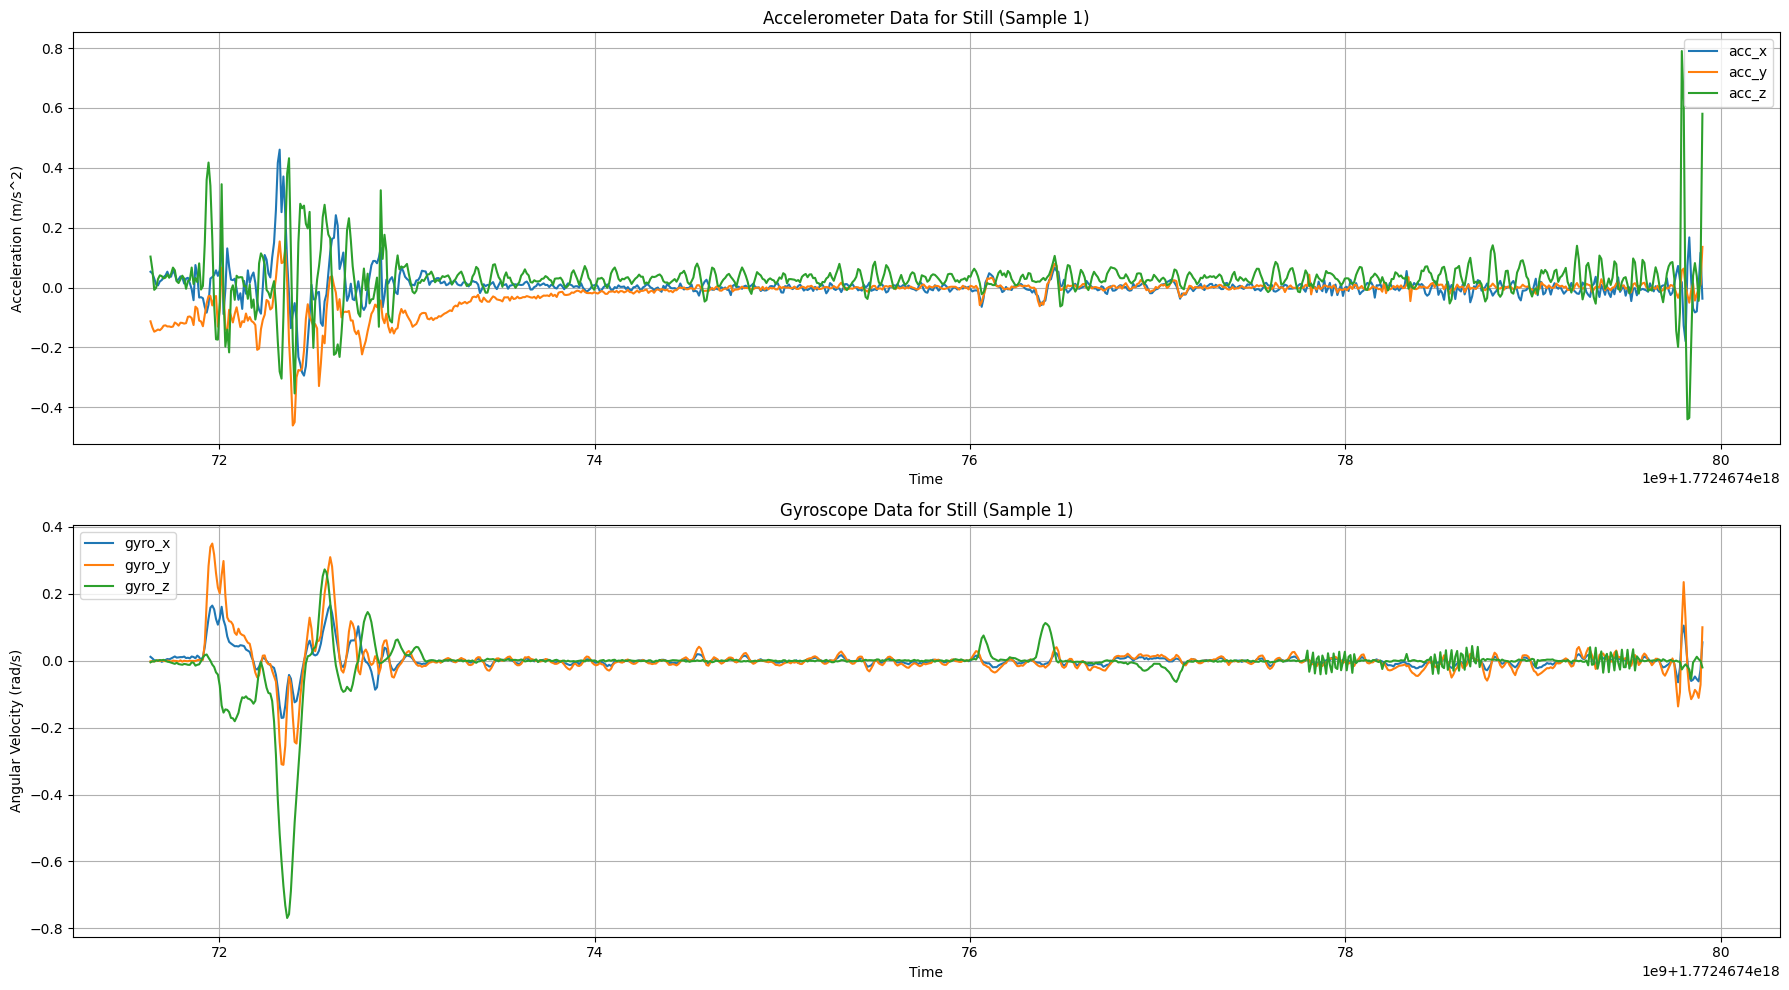

--- Sample 2 for Still ---
Shape: (900, 9)
Descriptive Statistics:
               time  seconds_elapsed_acc       acc_z       acc_y       acc_x  \
count  9.000000e+02           900.000000  900.000000  900.000000  900.000000   
mean   1.772714e+18             4.578370    0.014062    0.000953    0.000696   
std    2.592900e+09             2.592900    0.185945    0.058780    0.076057   
min    1.772714e+18             0.094808   -3.662557   -0.840884   -1.634281   
25%    1.772714e+18             2.336593    0.007310   -0.001748   -0.003154   
50%    1.772714e+18             4.578372    0.017768    0.001870    0.000093   
75%    1.772714e+18             6.820149    0.028327    0.004790    0.003529   
max    1.772714e+18             9.061918    2.127449    0.966461    1.198184   

       seconds_elapsed_gyro      gyro_z      gyro_y      gyro_x  
count            900.000000  900.000000  900.000000  900.000000  
mean               4.578370   -0.004235   -0.000405   -0.000285  
std           

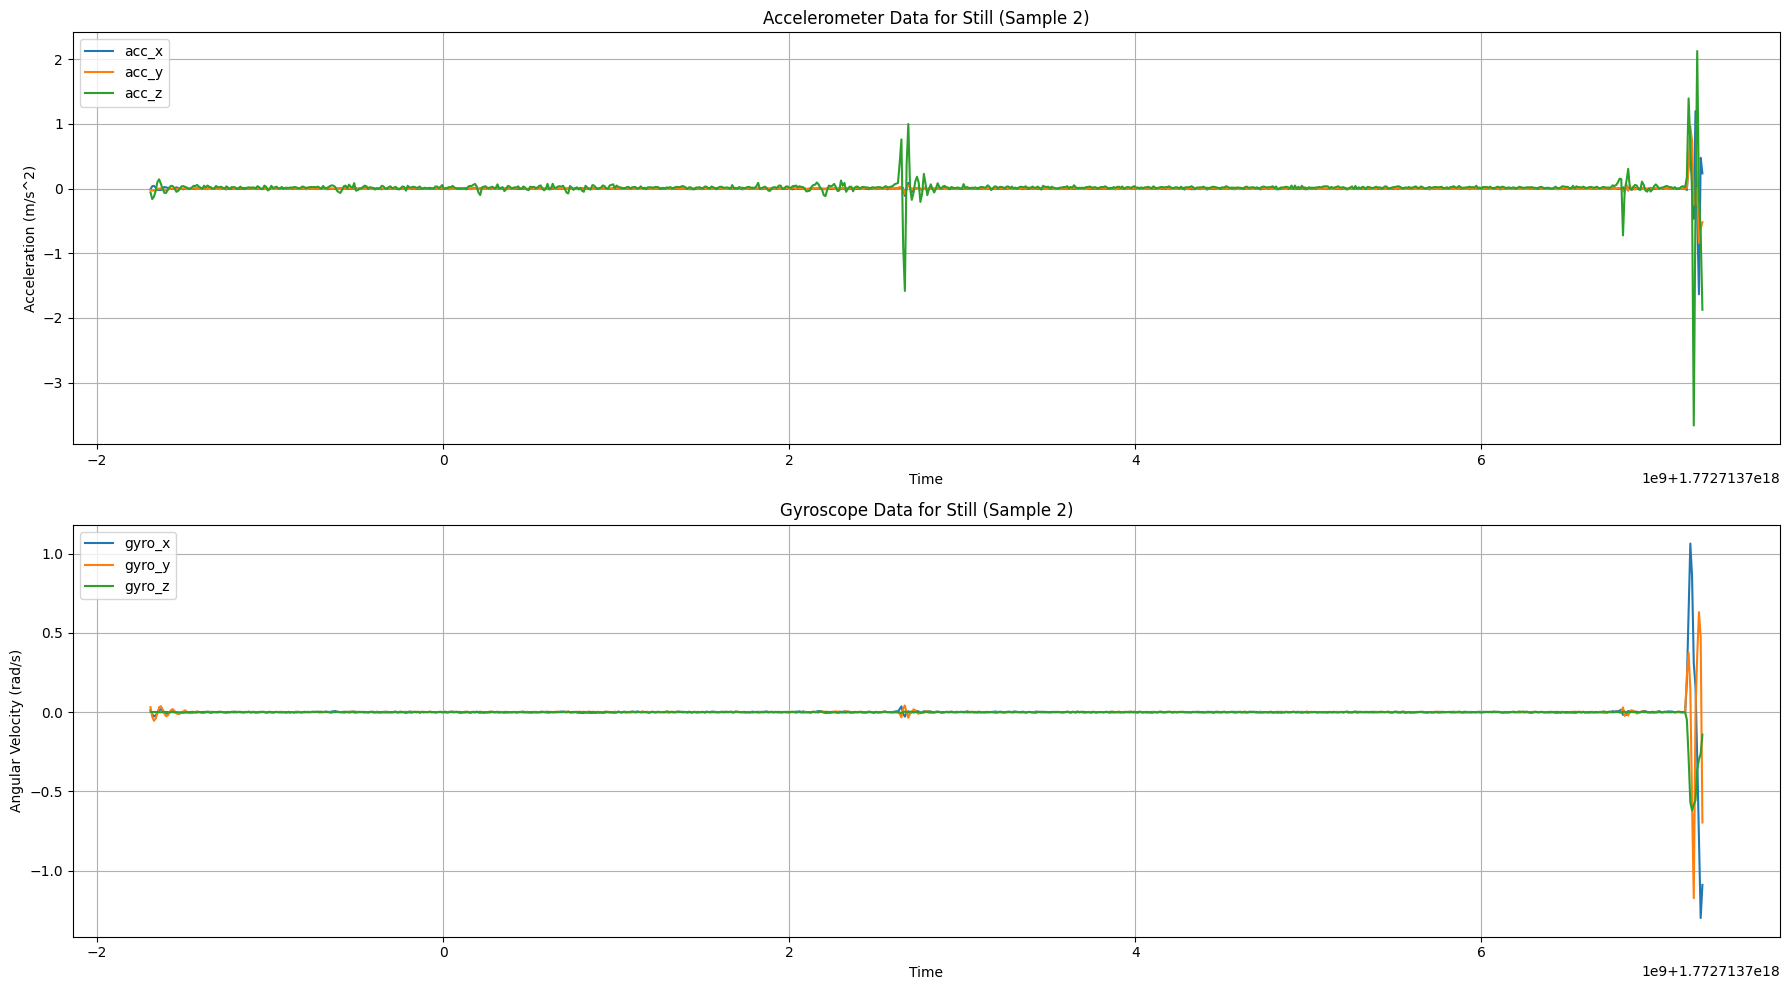

--- Sample 3 for Still ---
Shape: (1339, 9)
Descriptive Statistics:
               time  seconds_elapsed_acc        acc_z        acc_y  \
count  1.339000e+03          1339.000000  1339.000000  1339.000000   
mean   1.772563e+18             6.804493     0.067804    -0.014197   
std    3.892802e+09             3.892802     0.088074     0.014320   
min    1.772563e+18             0.069513    -0.585056    -0.258897   
25%    1.772563e+18             3.437002     0.060967    -0.019750   
50%    1.772563e+18             6.804493     0.067677    -0.014328   
75%    1.772563e+18            10.171984     0.074703    -0.008121   
max    1.772563e+18            13.539474     1.348079     0.102167   

             acc_x  seconds_elapsed_gyro       gyro_z       gyro_y  \
count  1339.000000           1339.000000  1339.000000  1339.000000   
mean     -0.003985              6.804493     0.000084    -0.000110   
std       0.029594              3.892802     0.001582     0.031704   
min      -0.269650   

In [20]:
print("\n--- Examining Raw Data for 'Jumping' and 'Still' Activities ---\n")

# Group data by activity for easier access
activity_data_map = {
    activity_name: [df for i, df in enumerate(data) if labels[i] == activity_name]
    for activity_name in ACTIVITIES
}

# Examine 'jumping' and 'still' activities
for activity_name in ['jumping', 'still']:
    print(f"\n### Activity: {activity_name.capitalize()}\n")
    activity_dfs = activity_data_map.get(activity_name, [])

    if not activity_dfs:
        print(f"No data found for '{activity_name}'.")
        continue

    for i, df_activity in enumerate(activity_dfs):
        print(f"--- Sample {i+1} for {activity_name.capitalize()} ---")
        print(f"Shape: {df_activity.shape}")
        print("Descriptive Statistics:")
        print(df_activity.describe())
        print("\n")

        # Visualize a few samples of raw data
        if i < 2: # Visualize up to 2 samples for brevity
            plt.figure(figsize=(18, 10))

            # Accelerometer data
            plt.subplot(2, 1, 1)
            plt.plot(df_activity['time'], df_activity['acc_x'], label='acc_x')
            plt.plot(df_activity['time'], df_activity['acc_y'], label='acc_y')
            plt.plot(df_activity['time'], df_activity['acc_z'], label='acc_z')
            plt.title(f'Accelerometer Data for {activity_name.capitalize()} (Sample {i+1})')
            plt.xlabel('Time')
            plt.ylabel('Acceleration (m/s^2)')
            plt.legend()
            plt.grid(True)

            # Gyroscope data
            plt.subplot(2, 1, 2)
            plt.plot(df_activity['time'], df_activity['gyro_x'], label='gyro_x')
            plt.plot(df_activity['time'], df_activity['gyro_y'], label='gyro_y')
            plt.plot(df_activity['time'], df_activity['gyro_z'], label='gyro_z')
            plt.title(f'Gyroscope Data for {activity_name.capitalize()} (Sample {i+1})')
            plt.xlabel('Time')
            plt.ylabel('Angular Velocity (rad/s)')
            plt.legend()
            plt.grid(True)

            plt.tight_layout()
            plt.show()


### Examine Raw Sensor Data

We look at the raw accelerometer and gyroscope data for jumping and still activities. This helps us understand what the sensor signals look like for different activities.

In [24]:
SAMPLING_RATE = 100
WINDOW_SIZE   = 100
STEP_SIZE     = 25

activity_data_map = {act: [] for act in ACTIVITIES}
for df, lbl in zip(data, labels):
    activity_data_map[lbl].append(df)

fig.suptitle('Easiest vs Hardest Activities to Distinguish',
             fontsize=15, fontweight='bold')

COLORS = {
    'jumping' : {'acc': '#E74C3C', 'gyro': '#C0392B'},
    'still'   : {'acc': '#2ECC71', 'gyro': '#27AE60'},
    'standing': {'acc': '#3498DB', 'gyro': '#2980B9'},
}

def get_sample(activity):
    sessions = activity_data_map.get(activity, [])
    if not sessions:
        print(f'⚠ No data found for activity: {activity}')
        return None
    return sessions[0]

pairs = [
    ('jumping',  'still', 'EASIEST to distinguish'),
    ('standing', 'still', 'HARDEST to distinguish'),
]

for row, (act_a, act_b, title) in enumerate(pairs):
    df_a = get_sample(act_a)
    df_b = get_sample(act_b)

    if df_a is None or df_b is None:
        print(f'⚠ Skipping row {row} — missing data for {act_a} or {act_b}')
        continue

    n_samples = min(500, len(df_a), len(df_b))


    ax = axes[row, 0]
    for act, df in [(act_a, df_a), (act_b, df_b)]:
        t = np.arange(n_samples) / SAMPLING_RATE
        ax.plot(t, df['acc_z'].values[:n_samples],
                label=act.capitalize(),
                color=COLORS[act]['acc'], linewidth=0.9, alpha=0.85)
    ax.set_title(f'{title}\nacc_z time-series (first 5 s)', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('acc_z (m/s²)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for act, df in [(act_a, df_a), (act_b, df_b)]:
        signal   = df['acc_z'].values[:WINDOW_SIZE]
        freqs    = np.fft.rfftfreq(WINDOW_SIZE, d=1/SAMPLING_RATE)
        spectrum = np.abs(np.fft.rfft(signal))
        ax.plot(freqs, spectrum,
                label=act.capitalize(),
                color=COLORS[act]['acc'], linewidth=1.2, alpha=0.85)
    ax.set_title(f'{title}\nFFT Spectrum — acc_z', fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, 15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvspan(1.5, 4.0, alpha=0.08, color='red')


ax_std  = axes[2, 0]
ax_kurt = axes[2, 1]

compare_activities = ['jumping', 'still', 'standing', 'walking']
feat_colors        = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

std_means, std_errs, kurt_means, kurt_errs = [], [], [], []

for act in compare_activities:
    sessions = activity_data_map.get(act, [])
    stds, kurts = [], []
    for df in sessions:
        if 'acc_z' not in df.columns:
            continue
        sig = df['acc_z'].values
        for start in range(0, len(sig) - WINDOW_SIZE, STEP_SIZE):
            w = sig[start:start + WINDOW_SIZE]
            stds.append(np.std(w))
            kurts.append(kurtosis(w))
    std_means.append(np.mean(stds)   if stds  else 0)
    std_errs.append(np.std(stds)     if stds  else 0)
    kurt_means.append(np.mean(kurts) if kurts else 0)
    kurt_errs.append(np.std(kurts)   if kurts else 0)

x = np.arange(len(compare_activities))

# Std bar chart
bars = ax_std.bar(x, std_means, yerr=std_errs, capsize=5,
                  color=feat_colors, edgecolor='black', linewidth=0.8,
                  error_kw={'elinewidth': 1.5})
ax_std.set_xticks(x)
ax_std.set_xticklabels([a.capitalize() for a in compare_activities])
ax_std.set_title('Standard Deviation of acc_z per Window\n(mean ± std across all windows)',
                 fontweight='bold')
ax_std.set_ylabel('Std (m/s²)')
ax_std.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, std_means):
    ax_std.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Kurtosis bar chart
bars2 = ax_kurt.bar(x, kurt_means, yerr=kurt_errs, capsize=5,
                    color=feat_colors, edgecolor='black', linewidth=0.8,
                    error_kw={'elinewidth': 1.5})
ax_kurt.set_xticks(x)
ax_kurt.set_xticklabels([a.capitalize() for a in compare_activities])
ax_kurt.set_title('Kurtosis of acc_z per Window\n(mean ± std across all windows)',
                  fontweight='bold')
ax_kurt.set_ylabel('Kurtosis')
ax_kurt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_kurt.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, kurt_means):
    ax_kurt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.1 if val >= 0 else -0.4),
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


print('\n Feature Separation Summary (acc_z)')
print(f'  {"Activity":<12} {"Std Mean":>10} {"Kurtosis Mean":>15}')
print(f'  {"-"*40}')
for act, sm, km in zip(compare_activities, std_means, kurt_means):
    print(f'  {act:<12} {sm:>10.4f} {km:>15.4f}')

print('\n Key insight:')
print('  Jumping vs Still  → large std gap + high kurtosis for jumping  → EASY to separate')
print('  Standing vs Still → near-identical std + kurtosis              → HARD to separate')

<Figure size 640x480 with 0 Axes>


 Feature Separation Summary (acc_z)
  Activity       Std Mean   Kurtosis Mean
  ----------------------------------------
  jumping         13.8487          0.4716
  still            0.0211          1.6368
  standing         0.1013          0.0166
  walking          0.9795         -0.2415

 Key insight:
  Jumping vs Still  → large std gap + high kurtosis for jumping  → EASY to separate
  Standing vs Still → near-identical std + kurtosis              → HARD to separate


### Activity Comparison Analysis

This detailed analysis compares activities to see which ones are easy to tell apart (like jumping vs still) and which ones are harder to distinguish (like standing vs still). We use various visualizations including:
- Time-series plots showing how signals change over time
- Frequency analysis (FFT) to see patterns in different frequency ranges
- Statistical features like standard deviation and kurtosis to measure signal variability

This helps us understand why some activities are easier for the model to recognize than others.